In [1]:
%load_ext autoreload
%autoreload 2

import os
print(f"Current working directory: {os.getcwd()}")

Current working directory: /teamspace/studios/this_studio/cifar100-benchmark


In [2]:
import torchvision
import torchvision.transforms as transforms
import torch
from torch.utils.data import random_split

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# 加载完整训练集
full_trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)

# 将训练集按8:2比例分割为训练集和验证集
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False)

# 测试集保持不变
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [3]:
from networks import CNN
from utils import check_model


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
check_model(model, num_classes=100, batch_size=4, device=device)



device: cuda:0
batch_size: 4
num_classes: 100
Forward pass output shape: torch.Size([4, 100])
test_target shape: torch.Size([4])
Test loss: 5.1410
损失计算成功


In [4]:
from utils import train_model

model = CNN(num_classes=100, in_channels=3, dropout_rate=0.5).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 100


In [5]:
train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    device,
    num_epochs,
    save_dir="logs/CNN_100epochs_definition",
    save_log=True,
    # pretrained="/output/cifar100-benchmark/logs/CNN/log_4/best_model_top1:0.5055_in_epoch1.pth"
)

print("Training complete")

不使用预训练模型


日志和模型将保存到: logs/CNN_100epochs_definition/log_3

------------------------------------------------
Epoch 1/100


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 4.3743, Top 1: 0.0345, Top 5: 0.1404
Val Loss: 4.0227, Top 1: 0.0970, Top 5: 0.2795
当前最佳top1准确率: 0.0970 in epoch 1
------------------------------------------------
Epoch 2/100


Train Loss: 4.1413, Top 1: 0.0595, Top 5: 0.2071
Val Loss: 3.8104, Top 1: 0.1158, Top 5: 0.3479
当前最佳top1准确率: 0.1158 in epoch 2
------------------------------------------------
Epoch 3/100


Train Loss: 4.0207, Top 1: 0.0703, Top 5: 0.2386
Val Loss: 3.6777, Top 1: 0.1337, Top 5: 0.3951
当前最佳top1准确率: 0.1337 in epoch 3
------------------------------------------------
Epoch 4/100


...

Train Loss: 2.4297, Top 1: 0.3472, Top 5: 0.6856
Val Loss: 2.2676, Top 1: 0.4184, Top 5: 0.7238
------------------------------------------------
Epoch 99/100


Train Loss: 2.4445, Top 1: 0.3412, Top 5: 0.6801
Val Loss: 2.2775, Top 1: 0.4151, Top 5: 0.7267
------------------------------------------------
Epoch 100/100


Train Loss: 2.4247, Top 1: 0.3458, Top 5: 0.6838
Val Loss: 2.2608, Top 1: 0.4145, Top 5: 0.7238
加载最佳模型，进行测试


Testing: 100%|██████████| 157/157 [00:02<00:00, 77.01it/s, loss=2.29, top 1=0.42, top 5=0.735] 

Test Loss: 2.2337, Top 1: 0.4204, Top 5: 0.7346
Training complete


In [6]:
from utils import predict

predict(model, 
        test_loader, 
        device, 
        pretrained=None)

 

Top 1 Accuracy: 0.4204, Top 5 Accuracy: 0.7346


(0.4204, 0.7346)

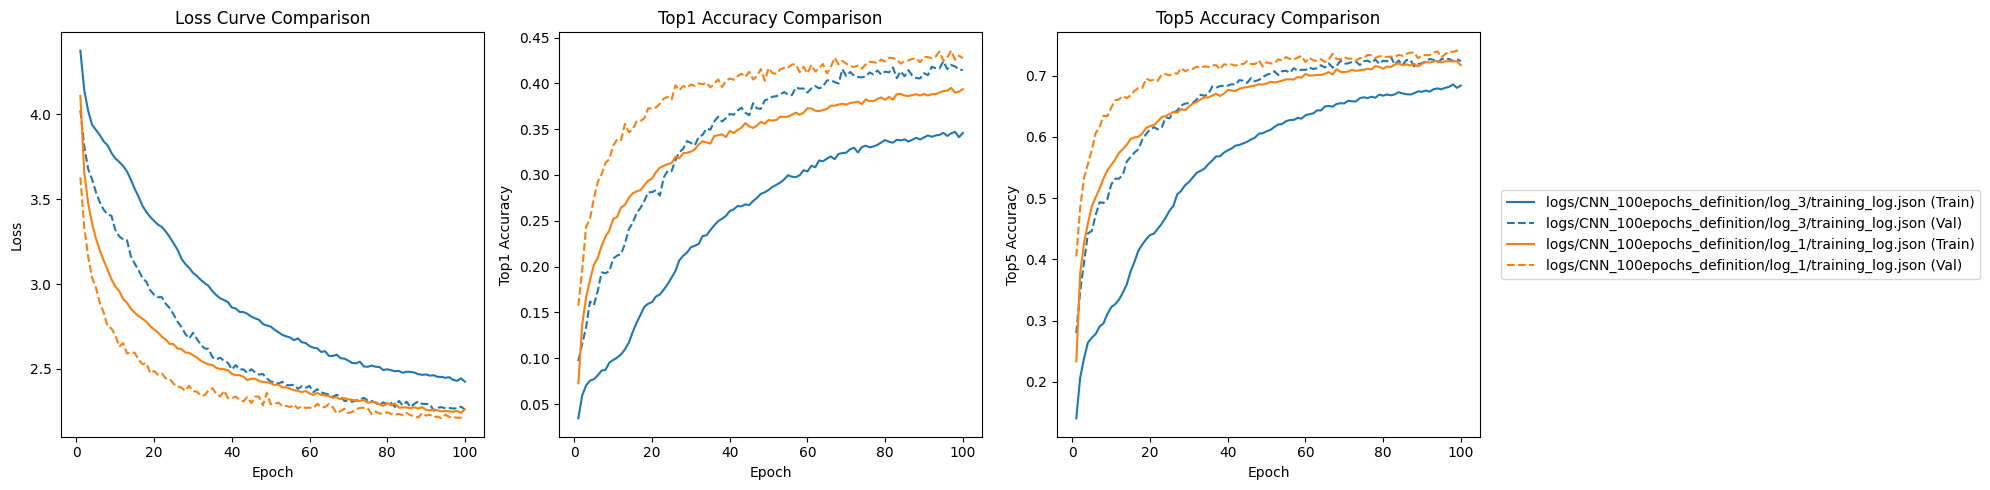

In [1]:
from utils import logshow, logshow_multi
    
# logshow('logs/CNN_100epochs_definition/log_3/training_log.json',
#         save_path='images/')

logshow_multi(['logs/CNN_100epochs_definition/log_3/training_log.json', 
               'logs/CNN_100epochs_definition/log_1/training_log.json'],
               save_path='images/')